https://colab.research.google.com/github/Daniel-534/MecanicaCeleste/blob/main/Modelacion3/CRTBP_Jupiter.ipynb

In [1]:
!pip install -Uq pymcel celluloid

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.5 MB/s eta 0:00:00


In [2]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt
from celluloid import Camera
from IPython.display import HTML, display

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


In [7]:
Epochs = {'start': '2026-06-16', 'stop': '2027-06-16', 'step': '5d'}

cuerpos = {
    "Sol": "10",                        # 1
    "Jupiter": "599",                   # 2
    "624_Hector": "DES=2000624;",       # 3
    "153_Hilda": "DES=2000153",         # 4
    "617_Patroclus": "DES=2000617",     # 5
    "Lucy": "-49"                       # 6
}

all_tablas = {}
all_tiempo_jd = {}
all_vector_estado = {}

for name, body_id in cuerpos.items():
  tabla_body, tiempo_jd_body, vector_estado_body = pc.consulta_horizons(
      id=body_id,
      location='@0',
      epochs=Epochs,
      datos='vectors',
  )

  all_tablas[name] = tabla_body
  all_tiempo_jd[name] = tiempo_jd_body
  all_vector_estado[name] = vector_estado_body

tabla = all_tablas
tiempo_jd = all_tiempo_jd
vector_estado = all_vector_estado

In [8]:
pos_sol = np.linalg.norm(vector_estado["Sol"][["x","y","z"]].iloc[0].to_numpy())
pos_jupiter = np.linalg.norm(vector_estado["Jupiter"][["x","y","z"]].iloc[0].to_numpy())
dist = pos_jupiter - pos_sol
print(dist)

787157329573.4178


In [9]:
G = pc.constantes.G
m1 = pc.constantes.M_sun   # Masa del Sol
m2 = pc.constantes.M_jup   # Masa de Jupiter

m3 = 7.91e18   # 624_Hector
m4 = 5.20e18   # 153_Hilda
m5 = 1.36e18   # 617_Patroclus
m6 = 1.55e3    # Lucy (Masa de lanzamiento)

a = 787157329573.4178

# Definimos unidades canonicas
U_M = m1+m2
U_L = a
U_T = np.sqrt(U_L**3/(G*U_M))
U_V = U_L/U_T

mu2 = m2*G / (G*U_M)
alpha = mu2
mu1 = 1-alpha

In [18]:
def transformar_a_CRTBP_frame(estado_si, m1_si, m2_si, U_L, U_V):

    # Validación y extracción dinámica de las 3 keys
    try:
        keys = list(estado_si.keys())
        if len(keys) != 3:
            raise ValueError(f"Se esperaban exactamente 3 keys en estado_si, pero se encontraron {len(keys)}.")

        # Desempaquetamos las 3 keys
        k1, k2, k3 = keys

    except ValueError as e:
        # Si falla la validación de longitud, relanzamos el error
        raise e
    except Exception as e:
        # Si estado_si no es un diccionario o falla al leer las keys
        raise TypeError(f"Error al procesar estado_si. Asegúrate de que sea un diccionario. Detalle: {e}")

    def get_vec(name):
        data = estado_si[name] # Usualmente esto es un dataframe
        if hasattr(data, 'values'): # Si es DataFrame
            return data[['x', 'y', 'z', 'vx', 'vy', 'vz']].iloc[0].to_numpy()
        else: # Si es array/lista
            return np.array(data[0]) # Asumiendo que es el primer instante

    r1_si = get_vec(k1)[:3]
    v1_si = get_vec(k1)[3:]

    r2_si = get_vec(k2)[:3]
    v2_si = get_vec(k2)[3:]

    r3_si = get_vec(k3)[:3]
    v3_si = get_vec(k3)[3:]

    # Calcular el Baricentro del sistema binario (m1 + m2)
    M_total = m1_si + m2_si

    r_cm_si = (m1_si * r1_si + m2_si * r2_si) / M_total
    v_cm_si = (m1_si * v1_si + m2_si * v2_si) / M_total

    # Trasladar al sistema centrado en el baricentro
    r_rel_si = r3_si - r_cm_si
    v_rel_si = v3_si - v_cm_si

    # Determinar el ángulo de rotación theta
    r12_si = r2_si - r1_si
    theta = np.arctan2(r12_si[1], r12_si[0])

    # Construir la Matriz de Rotación R(-theta)
    cos_t = np.cos(-theta)
    sin_t = np.sin(-theta)

    R = np.array([
        [cos_t, -sin_t, 0],
        [sin_t,  cos_t, 0],
        [0,      0,     1]
    ])

    # Aplicar la rotación a la posición relativa
    r_rot_si = np.dot(R, r_rel_si)

    r_can_inertial = r_rel_si / U_L
    v_can_inertial = v_rel_si / U_V

    # Ahora aplicamos la rotación a las cantidades canónicas
    r_can_rot = np.dot(R, r_can_inertial)

    # Corrección de velocidad por rotación del marco
    omega_can = np.array([0, 0, 1])
    omega_cross_r = np.cross(omega_can, r_can_rot)

    # Rotamos la velocidad inercial canónica
    v_can_inertial_rot = np.dot(R, v_can_inertial)

    # Velocidad final en el marco rotante canónico
    v_can_rot = v_can_inertial_rot - omega_cross_r

    # Ensamblar el vector de estado final
    Y_canonico = np.concatenate((r_can_rot, v_can_rot))

    return Y_canonico

In [19]:
cuerpos_fijos = ['Sol', 'Jupiter']
cuerpos_a_calcular = ['624_Hector', '153_Hilda', '617_Patroclus', 'Lucy']

resultados_Ys = {}

for cuerpo_menor in cuerpos_a_calcular:

    keys_necesarias = cuerpos_fijos + [cuerpo_menor]
    estado_si_reducido = {k: vector_estado[k] for k in keys_necesarias}

    x, y, z, vx, vy, vz = transformar_a_CRTBP_frame(
        estado_si_reducido, m1, m2, U_L, U_V
    )

    nombre_resultado = f"Ys_{cuerpo_menor}"
    resultados_Ys[nombre_resultado] = [x, y, z, vx, vy, vz]

Ys_Hector   = resultados_Ys['Ys_624_Hector']
Ys_Hilda    = resultados_Ys['Ys_153_Hilda']
Ys_Patroclus = resultados_Ys['Ys_617_Patroclus']
Ys_Lucy     = resultados_Ys['Ys_Lucy']

In [21]:
ts = np.linspace(0, 300, 10000)

rs_Hector, vs_Hector, ris_Hector, vis_Hector, r1s_Hector, r2s_Hector = pc.crtbp_solucion(alpha, resultados_Ys['Ys_624_Hector'][:3], resultados_Ys['Ys_624_Hector'][3:], ts)

rs_Hilda, vs_Hilda, ris_Hilda, vis_Hilda, r1s_Hilda, r2s_Hilda = pc.crtbp_solucion(alpha, resultados_Ys['Ys_153_Hilda'][:3], resultados_Ys['Ys_153_Hilda'][3:], ts)

rs_Patroclus, vs_Patroclus, ris_Patroclus, vis_Patroclus, r1s_Patroclus, r2s_Patroclus = pc.crtbp_solucion(alpha, resultados_Ys['Ys_617_Patroclus'][:3], resultados_Ys['Ys_617_Patroclus'][3:], ts)

rs_Lucy, vs_Lucy, ris_Lucy, vis_Lucy, r1s_Lucy, r2s_Lucy = pc.crtbp_solucion(alpha, resultados_Ys['Ys_Lucy'][:3], resultados_Ys['Ys_Lucy'][3:], ts)

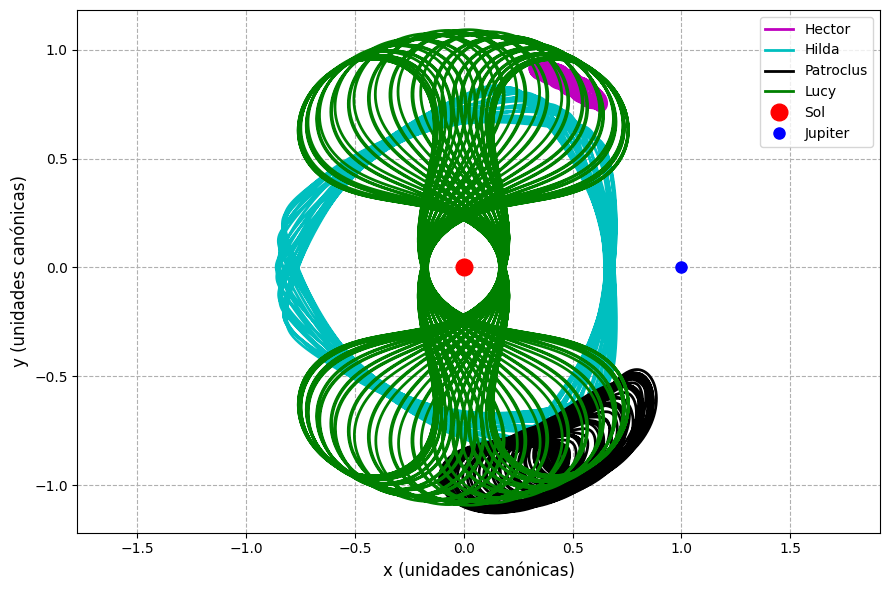

In [22]:
plt.figure(figsize=(6*1.5, 4*1.5))

plt.plot(rs_Hector[:,0], rs_Hector[:,1], "-m", lw=2, label="Hector")
plt.plot(rs_Hilda[:,0], rs_Hilda[:,1], "-c", lw=2, label="Hilda")
plt.plot(rs_Patroclus[:,0], rs_Patroclus[:,1], "-k", lw=2, label="Patroclus")
plt.plot(rs_Lucy[:,0], rs_Lucy[:,1], "-g", lw=2, label="Lucy")

plt.plot(-alpha, 0, 'o', color='red', markersize=12, label='Sol')
plt.plot(1 - alpha, 0, 'o', color='blue', markersize=8, label='Jupiter')

plt.xlabel('x (unidades canónicas)', fontsize=12)
plt.ylabel('y (unidades canónicas)', fontsize=12)
#plt.title('Trayectoria de Hiperión en el sistema Saturno-Titán (crtbp_solucion())', fontsize=14)

plt.grid(ls="--")
plt.axis('equal')

plt.legend()
plt.tight_layout();


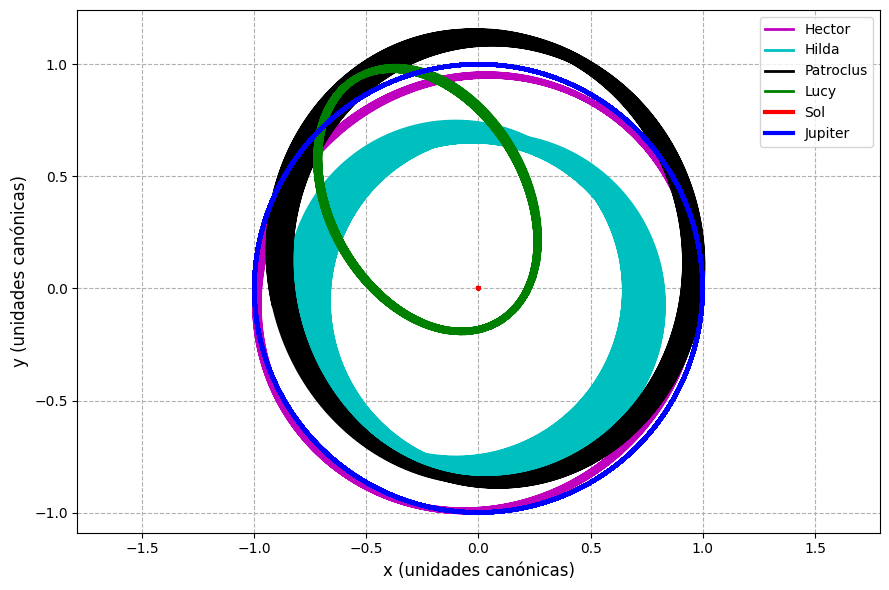

In [23]:
plt.figure(figsize=(6*1.5, 4*1.5))

plt.plot(ris_Hector[:,0], ris_Hector[:,1], "-m", lw=2, label="Hector")
plt.plot(ris_Hilda[:,0], ris_Hilda[:,1], "-c", lw=2, label="Hilda")
plt.plot(ris_Patroclus[:,0], ris_Patroclus[:,1], "-k", lw=2, label="Patroclus")
plt.plot(ris_Lucy[:,0], ris_Lucy[:,1], "-g", lw=2, label="Lucy")

plt.plot(r1s_Lucy[:,0], r1s_Lucy[:,1], color='red', linewidth=3, label='Sol')
plt.plot(r2s_Lucy[:,0], r2s_Lucy[:,1], color='blue', linewidth=3, label='Jupiter')


plt.xlabel('x (unidades canónicas)', fontsize=12)
plt.ylabel('y (unidades canónicas)', fontsize=12)

plt.grid(ls="--")
plt.axis('equal')

plt.legend()
plt.tight_layout();

In [24]:
Ng = 100
vmax = 1.5
xs = np.linspace(-vmax, vmax, Ng)
ys = np.linspace(-vmax, vmax, Ng)
Xs, Ys = np.meshgrid(xs, ys)

Zs = 0 * np.ones_like(Xs)
Xs.shape

(100, 100)

In [25]:
Vmods = np.zeros((Ng, Ng))
for iy in range(Ng):
  for ix in range(Ng):
    x = Xs[iy, ix]
    y = Ys[iy, ix]
    z = Zs[iy, ix]

    soft = 0.03
    x1 = -alpha
    x2 = 1 - alpha
    r1 = np.sqrt((x-x1)**2 + y**2 + z**2 + soft)
    r2 = np.sqrt((x-x2)**2 + y**2 + z**2 + soft)
    Vmods[iy, ix] = -(1-alpha)/r1 - alpha/r2 -1/2*(x**2+y**2)

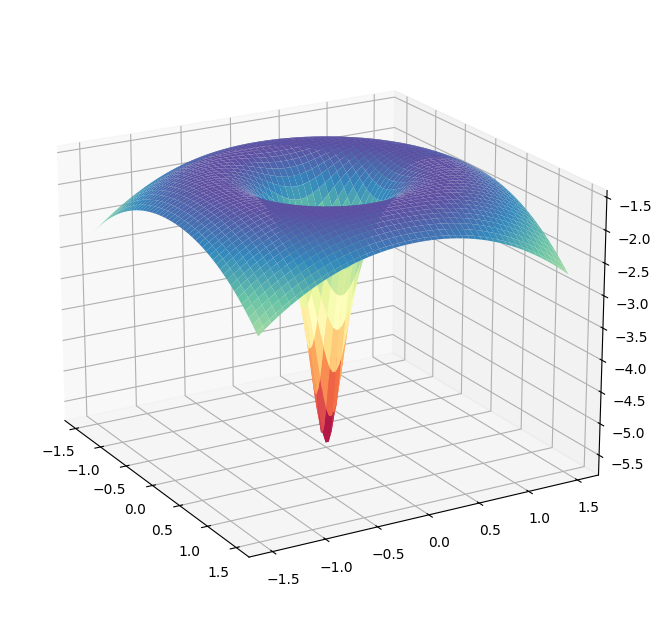

In [26]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
#ax.plot_surface(Xs, Ys, Vmods, cmap='viridis')
ax.plot_surface(Xs, Ys, Vmods, cmap='Spectral')
#ax.plot_surface(Xs, Ys, Vmods, cmap='inferno')
#ax.plot_surface(Xs, Ys, Vmods, cmap='prism')
ax.view_init(elev=20,azim=330)
plt.show()

In [27]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Surface(z=Vmods, x=Xs, y=Ys)])

fig.update_layout(title='Potencial Modificado en 3D (Plotly)', autosize=False,
                  scene_camera_eye=dict(x=1.86, y=0.18, z=0.61),
                  width=800, height=700,
                  margin=dict(l=65, r=50, b=65, t=90))

fig.show()

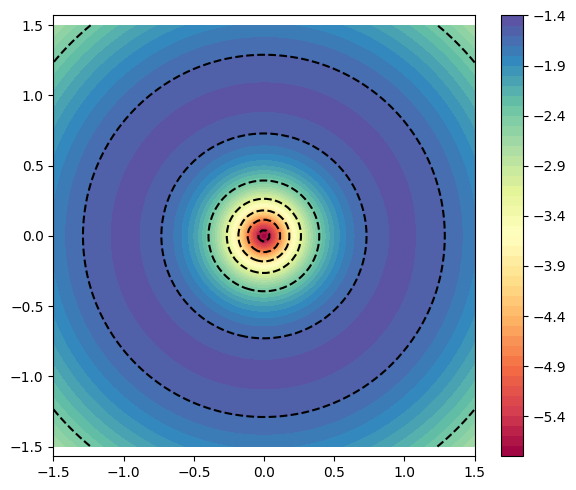

In [28]:
plt.figure(figsize=(6,5))

c1 = plt.contourf(Xs, Ys, Vmods, levels=50, cmap='Spectral')
plt.colorbar(c1)
c2 = plt.contour(Xs, Ys, Vmods, levels=5, colors='k')

plt.axis('equal')
plt.tight_layout()

In [29]:
xs = rs_Lucy[:,0]
ys = rs_Lucy[:,1]
zs = rs_Lucy[:,2]
vmags = np.linalg.norm(vs_Lucy,axis=1)
x1 = -alpha
x2 = 1-alpha
r1mags = ((xs-x1)**2 + ys**2 + zs**2)**0.5
r2mags = ((xs-x2)**2 + ys**2 + zs**2)**0.5

CJs = 2*(1-alpha) / r1mags + 2*alpha / r2mags + (xs**2 + ys**2) - vmags**2
CJ = CJs.mean()

In [30]:
x = -0.25
y = -0.6
z = 0

# Condición de exclusión/aceptación
r1 = ((x-x1)**2 + y**2 + z**2)**0.5
r2 = ((x-x2)**2 + y**2 + z**2)**0.5
v2 = 2*(1-alpha)/r1 + 2*alpha/r2 + x**2 + y**2 - CJ
v2

np.float64(0.8158437268284917)

In [31]:
x = -0.25
y = -1.6
z = 0

# Condición de exclusión/aceptación
r1 = ((x-x1)**2 + y**2 + z**2)**0.5
r2 = ((x-x2)**2 + y**2 + z**2)**0.5
v2 = 2*(1-alpha)/r1 + 2*alpha/r2 + x**2 + y**2 - CJ
v2

np.float64(1.1736346231043084)

In [32]:
Ng = 100
vmax = 2.0
xs = np.linspace(-vmax, vmax, Ng)
ys = np.linspace(-vmax, vmax, Ng)
Xs, Ys = np.meshgrid(xs, ys)
Zs = 0 * np.ones_like(Xs)

# Excluye la región muy cercana al Sol
mask = (Xs**2 + Ys**2 > 0.1)  # Evita la singularidad del Sol
Zs_masked = np.ma.masked_where(~mask, Zs)
# Condición de exclusión/aceptación
R1s = ((Xs-x1)**2 + Ys**2 + Zs**2)**0.5
R2s = ((Xs-x2)**2 + Ys**2 + Zs**2)**0.5
V2s = 2*(1-alpha)/R1s + 2*alpha/R2s + Xs**2 + Ys**2 - CJ

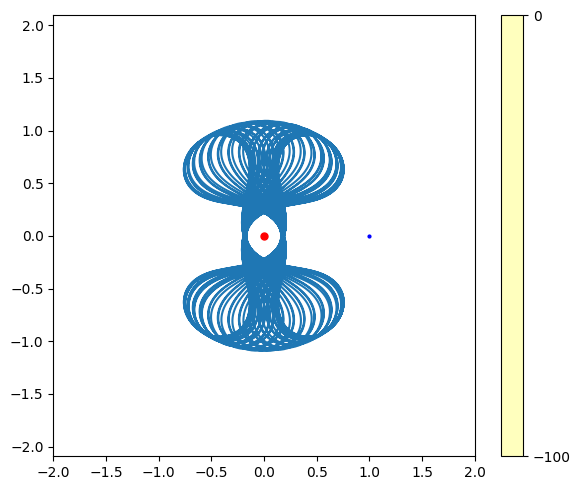

In [33]:
plt.figure(figsize=(6,5))

c1 = plt.contourf(Xs, Ys, V2s,
                  levels=[-100,0], cmap='Spectral')
plt.colorbar(c1)
# Superficie de cero velocidad
c2 = plt.contour(Xs, Ys, V2s,
                 levels=[0], colors='k')

plt.plot(-alpha, 0, 'ro', ms=5)
plt.plot(1-alpha, 0, 'bo', ms=2)
plt.plot(rs_Lucy[:, 0], rs_Lucy[:, 1])

plt.axis('equal')
plt.tight_layout()